# Segnature Inference

### Carico le metriche dai file in formato JSON

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
evalutaions_df = json.load(open('./results/models_evaluations.json'))

In [3]:
run_labels = evalutaions_df.keys()
run_labels = list(run_labels)
run_labels = run_labels[0:3]
print('Number of run_labels:',len(run_labels), run_labels)
print('-'*50)

sampling_labels = evalutaions_df[run_labels[0]].keys()
sampling_labels = list(sampling_labels)
print('Number of sampling_labels:',len(sampling_labels), sampling_labels)
print('-'*50)

signature_labels = evalutaions_df[run_labels[0]][sampling_labels[0]].keys()
signature_labels = list(signature_labels)
print('Number of signature_labels:',len(signature_labels), signature_labels)

Number of run_labels: 3 ['run_1', 'run_2', 'run_3']
--------------------------------------------------
Number of sampling_labels: 16 ['sampling_1', 'sampling_0.9', 'sampling_0.8', 'sampling_0.7', 'sampling_0.6', 'sampling_0.5', 'sampling_0.4', 'sampling_0.3', 'sampling_0.2', 'sampling_0.15', 'sampling_0.1', 'sampling_0.05', 'sampling_0.04', 'sampling_0.03', 'sampling_0.02', 'sampling_0.01']
--------------------------------------------------
Number of signature_labels: 29 ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', 'S6 (SBS7a - 1.00)', 'S7 (SBS7b - 0.96)', 'S8 (SBS8 - 0.92)', 'S9 (SBS9 - 0.94)', 'S10 (SBS10a - 1.00)', 'S11 (SBS10d - 0.98)', 'S12 (SBS11 - 0.99)', 'S13 (SBS13 - 0.99)', 'S14 (SBS14 - 0.98)', 'S15 (SBS15 - 0.97)', 'S16 (SBS17 - 0.99)', 'S17 (SBS18 - 0.97)', 'S18 (SBS19 - 0.95)', 'S19 (SBS20 - 0.98)', 'S20 (SBS22 - 0.99)', 'S21 (SBS23 - 0.94)', 'S22 (SBS26 - 0.94)', 'S23 (SBS28 - 0.96)', 'S24 (SBS31 - 0.98)', 'S25 (SBS

In [4]:
per_run_accuracy = []
for run in run_labels:
    per_sample_accuracy = []
    for sampling in sampling_labels:
        per_signature_accuracy = []
        for signature in signature_labels:
            # Save the accuracy of each signarure for one sample
            per_signature_accuracy.append(evalutaions_df[run][sampling][signature]['balanced_accuracy'])
        # Here we have the mean accuracy of all signatures for one sample
        per_sample_accuracy.append(per_signature_accuracy)
    # Here we have the mean accuracy of all samples for one run
    per_run_accuracy.append(per_sample_accuracy)

## Plot the graphs

### Statistiche sulle segnature

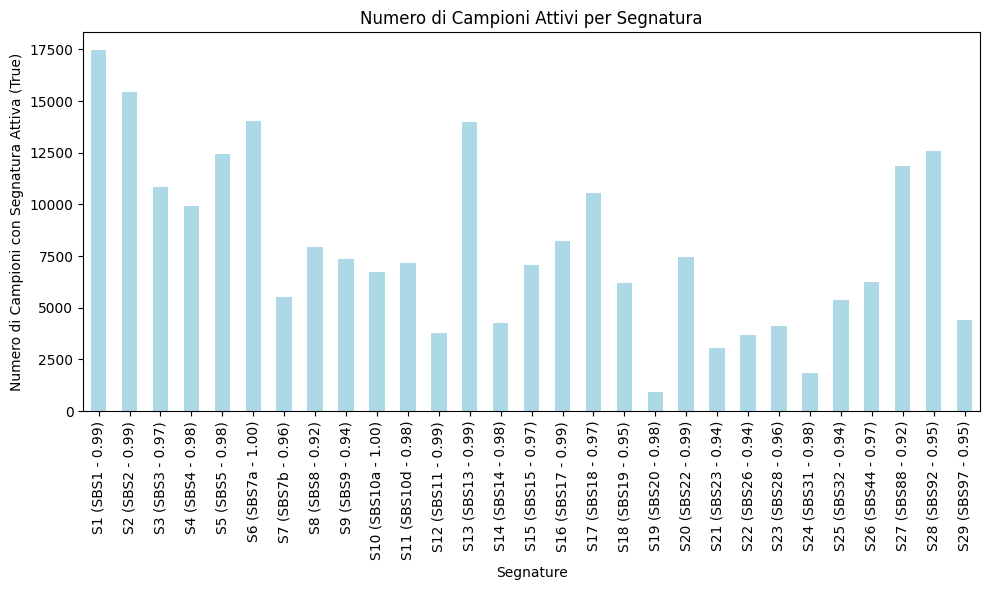

In [5]:
signature_gt_path = './simulations/ground_truth/bin_exposures.csv'

signature_gt_df = pd.read_csv(signature_gt_path)
signature_gt_df.head()

active_segnature = signature_gt_df.iloc[:, 1:].sum()
plt.figure(figsize=(10, 6))
active_segnature.plot(kind='bar', color='lightblue')
plt.xlabel('Segnature')
plt.ylabel('Numero di Campioni con Segnatura Attiva (True)')
plt.title('Numero di Campioni Attivi per Segnatura')
plt.xticks(rotation=90)  # Ruota le etichette sull'asse X per renderle leggibili
plt.tight_layout()
plt.show()

### Accuratezza per signature, per sample, per run
In questo grafico viene mostrato il livello di accuracy mediato ottenuto per ogni segnatura al variare del livello di sampling, per ogni run

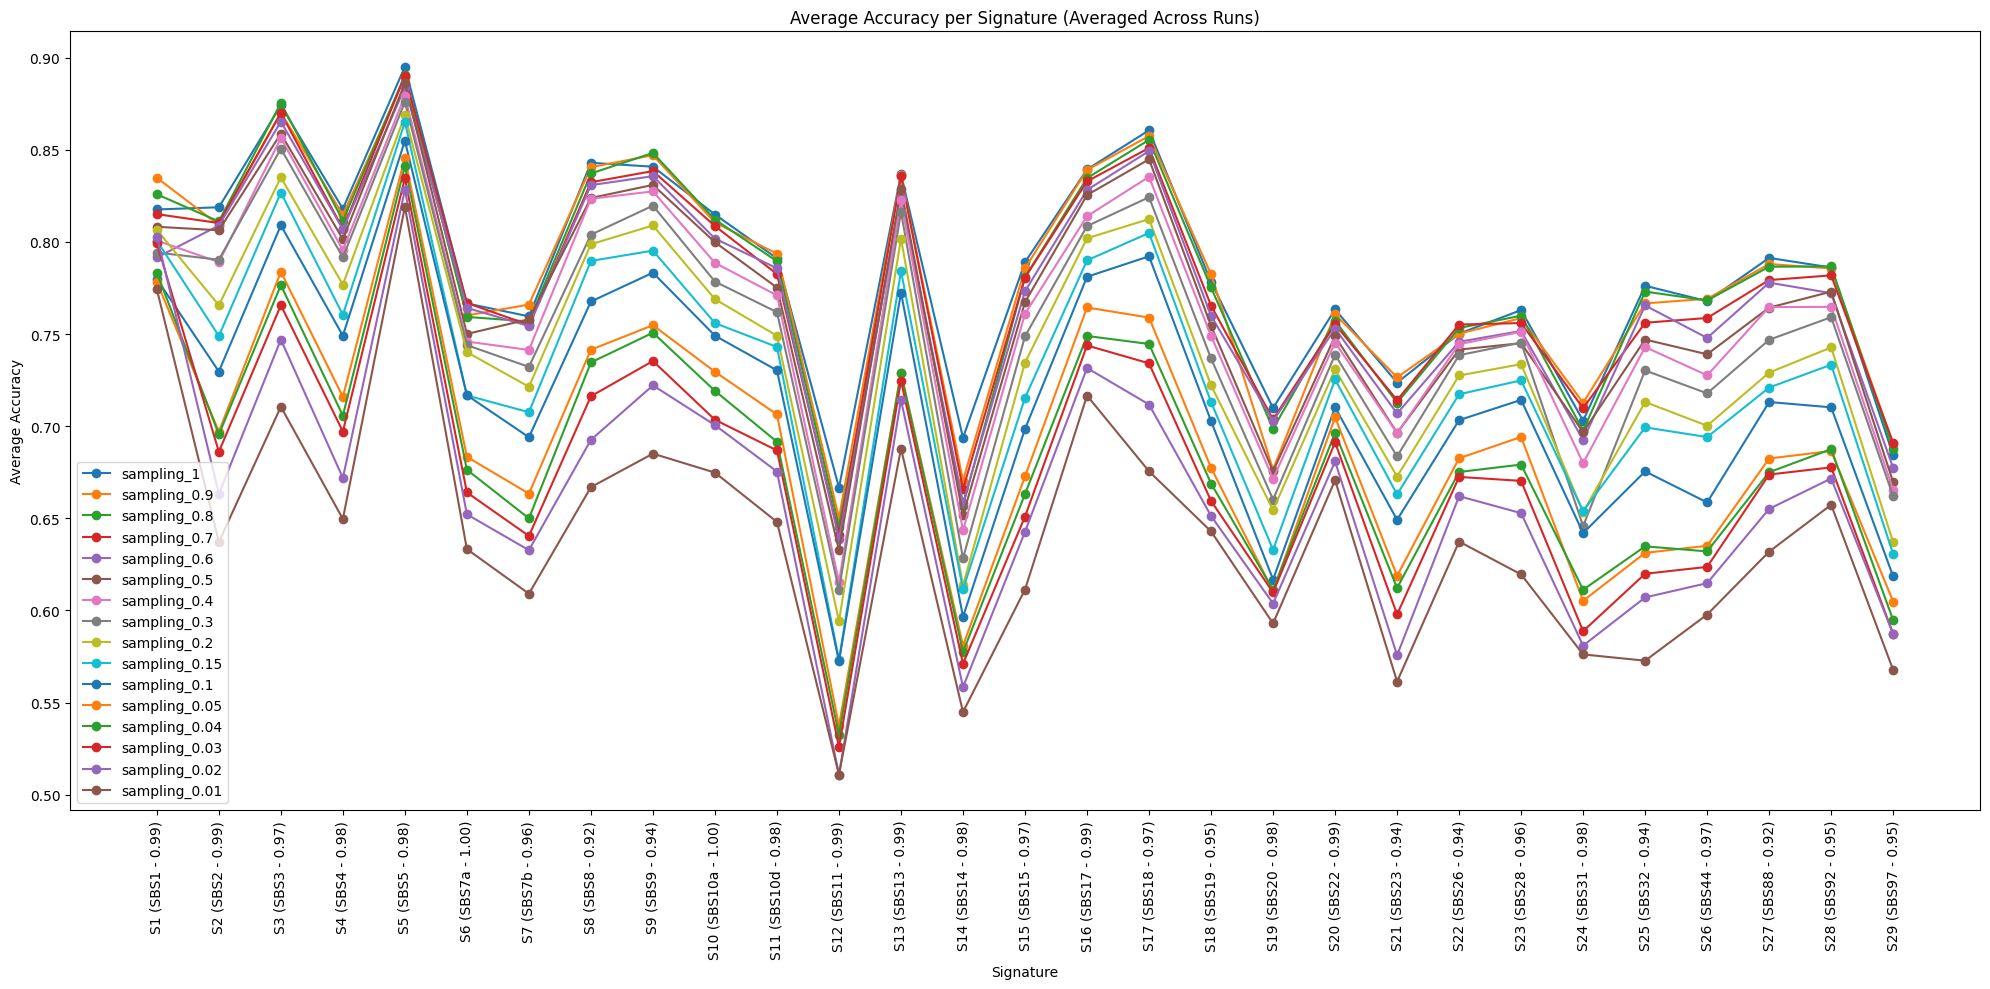

In [6]:
per_run_accuracy = np.array(per_run_accuracy)
mean_accuracy = np.mean(per_run_accuracy, axis=0)

plt.figure(figsize=(20, 10))

# Plotta la media per ogni campione (dimensione j di per_sample_accuracy)
for j in range(len(mean_accuracy)):
    plt.plot(signature_labels, mean_accuracy[j], marker='o', label=sampling_labels[j])

plt.legend(sampling_labels)
plt.xticks(rotation=90)
plt.ylabel('Average Accuracy')
plt.xlabel('Signature')
plt.title('Average Accuracy per Signature (Averaged Across Runs)')

plt.tight_layout()
plt.show()


### Accuratezza media per sample per run
In questo grafico venogno 

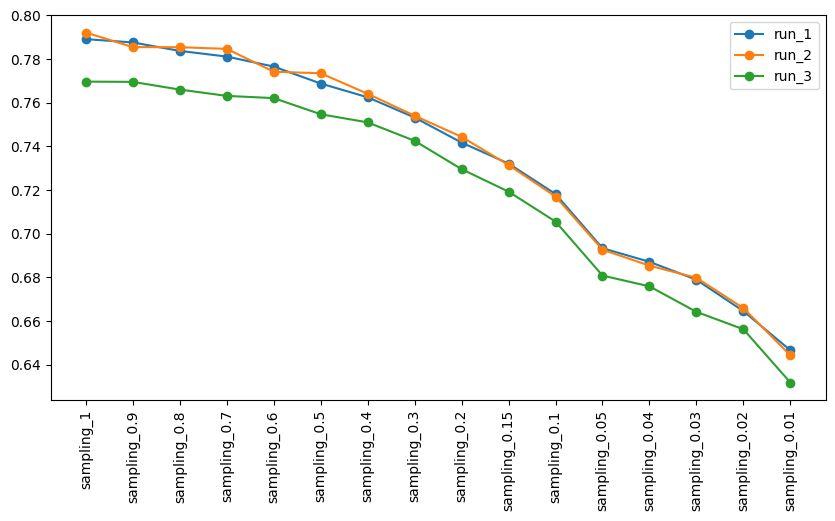

In [7]:
plt.figure(figsize=(10,5))
for i in range(len(per_run_accuracy)):
    per_sample_mean_accuracy = []
    per_sample_accuracy = per_run_accuracy[i]
    for j in range(len(per_sample_accuracy)):
        per_sample_mean_accuracy.append(np.mean(per_sample_accuracy[j]))

    plt.plot(sampling_labels,per_sample_mean_accuracy, marker='o')
    plt.xticks(rotation=90)

plt.legend(run_labels)
plt.show()

### Box-plot (Diagrammi scatola baffo)

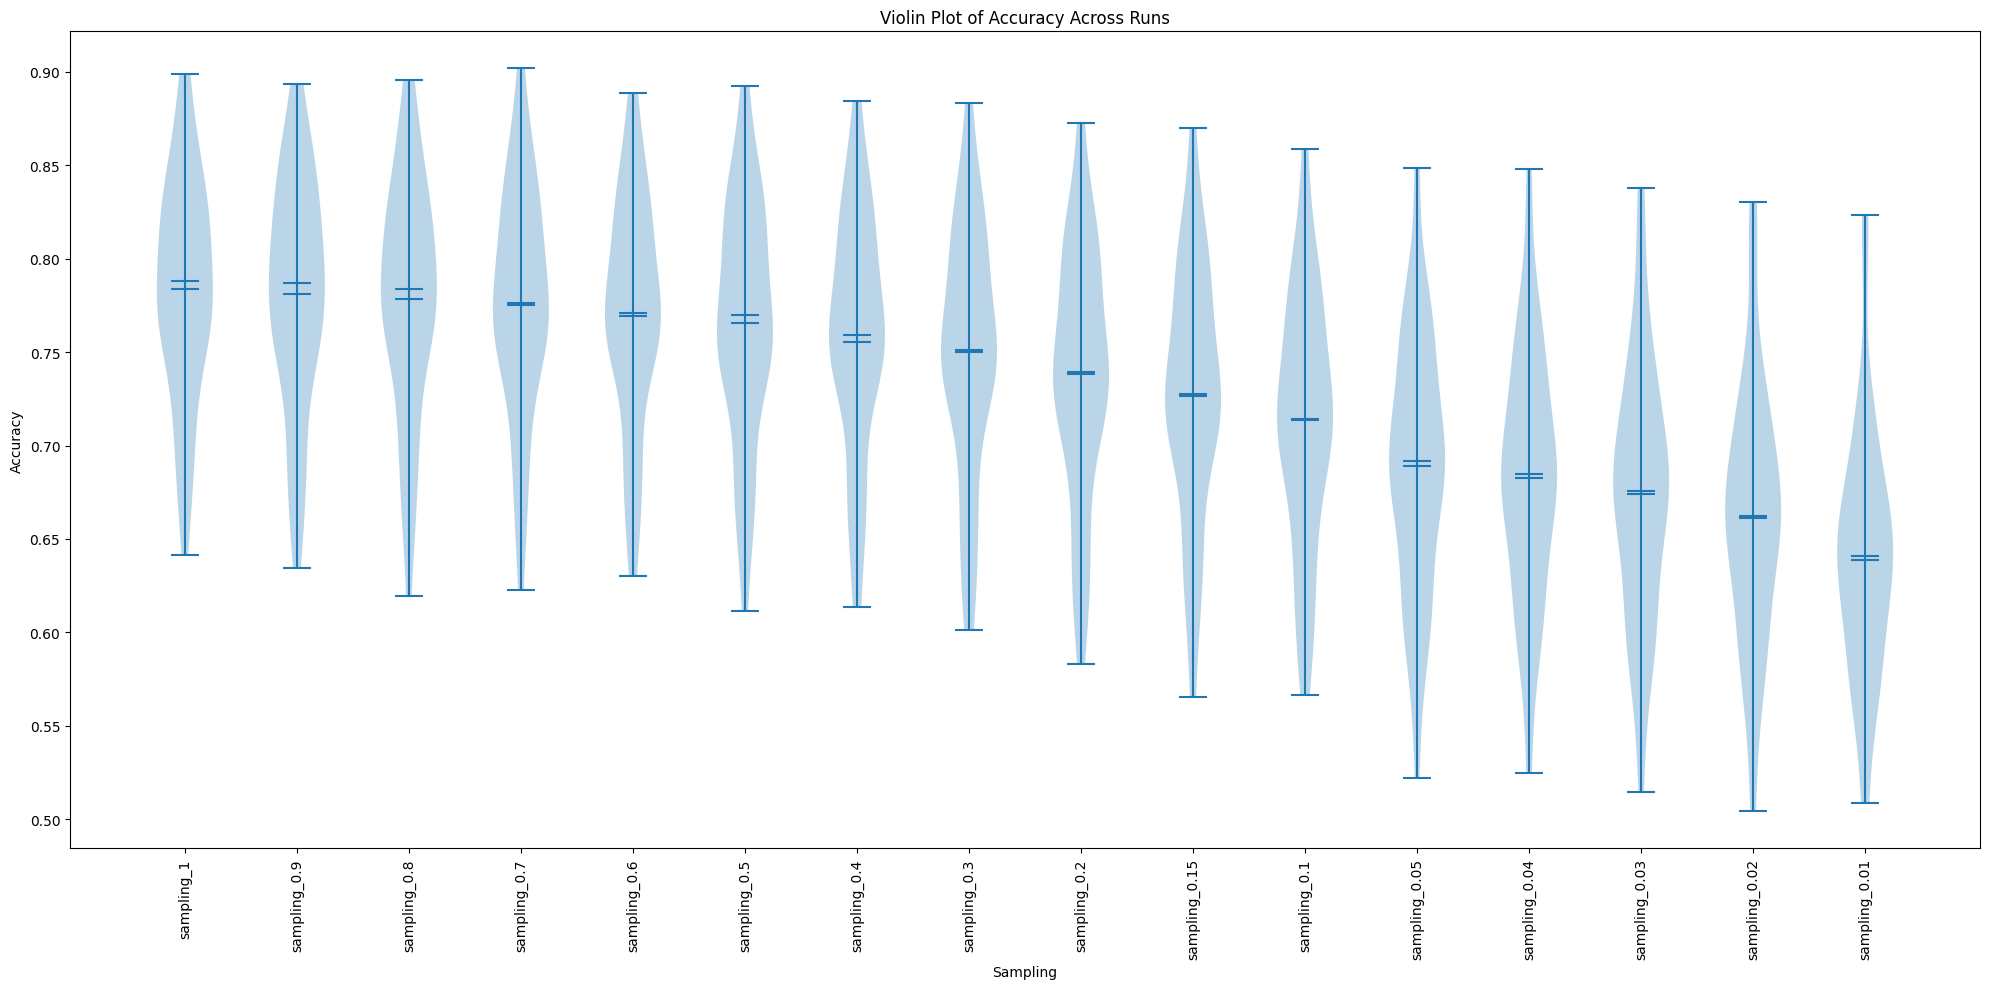

In [8]:
import numpy as np
import matplotlib.pyplot as plt

per_run_accuracy = np.array(per_run_accuracy)

plt.figure(figsize=(20, 10))
plt.xlabel('Sampling')
plt.xticks(range(1, len(sampling_labels) + 1), sampling_labels, rotation=90)
plt.ylabel('Accuracy')
plt.title('Violin Plot of Accuracy Across Runs')
plt.violinplot([per_run_accuracy[:, j, :].flatten() for j in range(len(sampling_labels))], showmeans=True, showmedians=True, showextrema=True)

plt.tight_layout()
plt.show()


### ROC Curve & AUC 

### Best Models

In [9]:
import seaborn as sns
best_model_df = json.load(open('./results/models_evaluations.json'))
models = []
for run in run_labels:
    for sampling in sampling_labels:
        for signature in signature_labels:
            best_model = best_model_df[run][sampling][signature]['best_model']
            if best_model not in models:
                models.append(best_model)
    break

In [10]:
for run in run_labels:
    sample_best_model_df = pd.DataFrame(columns=models, index=sampling_labels).fillna(0)
    signature_best_model_df = pd.DataFrame(columns=models, index=signature_labels).fillna(0)
    for sampling in sampling_labels:
        for signature in signature_labels:
            best_model = best_model_df[run][sampling][signature]['best_model']
            sample_best_model_df.loc[sampling,best_model] += 1

    for sampling in sampling_labels:
        for signature in signature_labels:
            best_model = best_model_df[run][sampling][signature]['best_model']
            signature_best_model_df.loc[signature,best_model] += 1
    break

/tmp/ipykernel_14065/4061301732.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample_best_model_df = pd.DataFrame(columns=models, index=sampling_labels).fillna(0)
/tmp/ipykernel_14065/4061301732.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  signature_best_model_df = pd.DataFrame(columns=models, index=signature_labels).fillna(0)


### Modelli migliori per i vari livelli di sampling

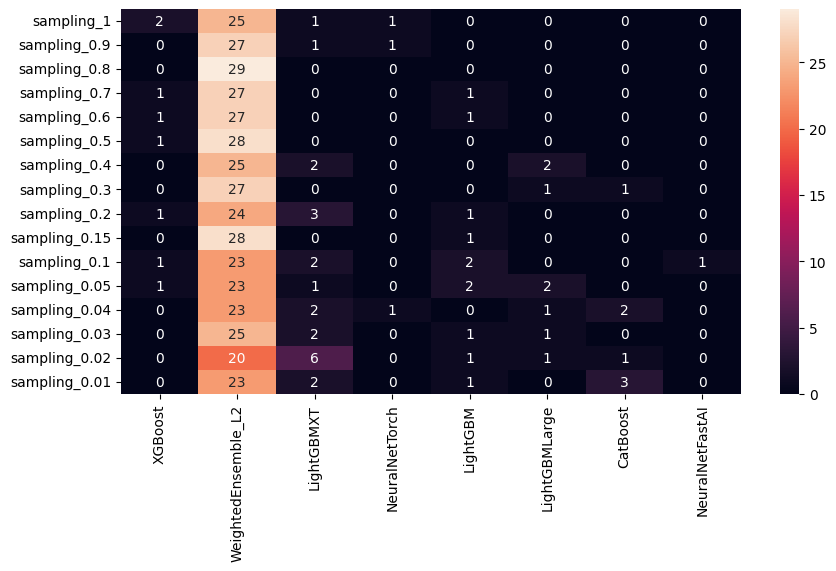

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(sample_best_model_df, annot=True, fmt="d")
plt.show()

### Modelli migliori per le signature

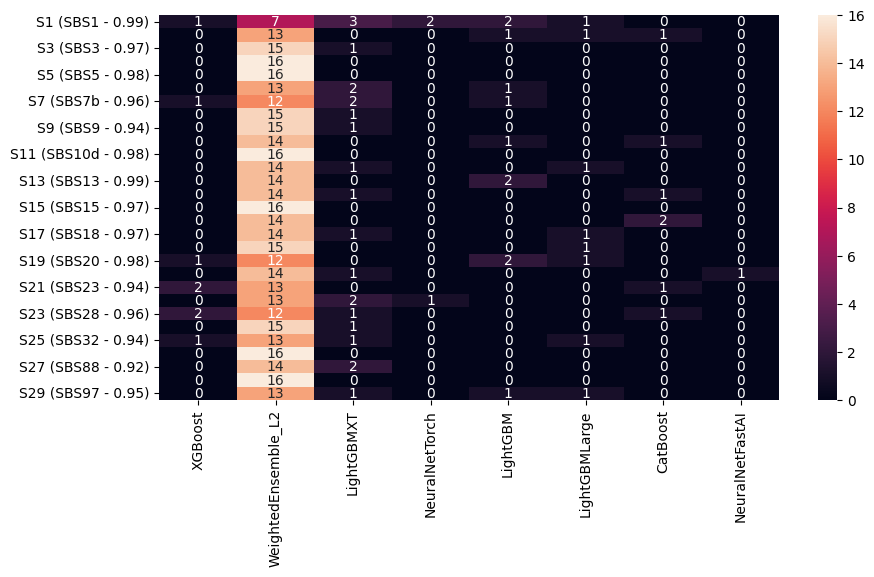

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(signature_best_model_df, annot=True, fmt="d")
plt.show()